C:\Users\aadil\AppData\Local\Temp\ipykernel_4920\166159119.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


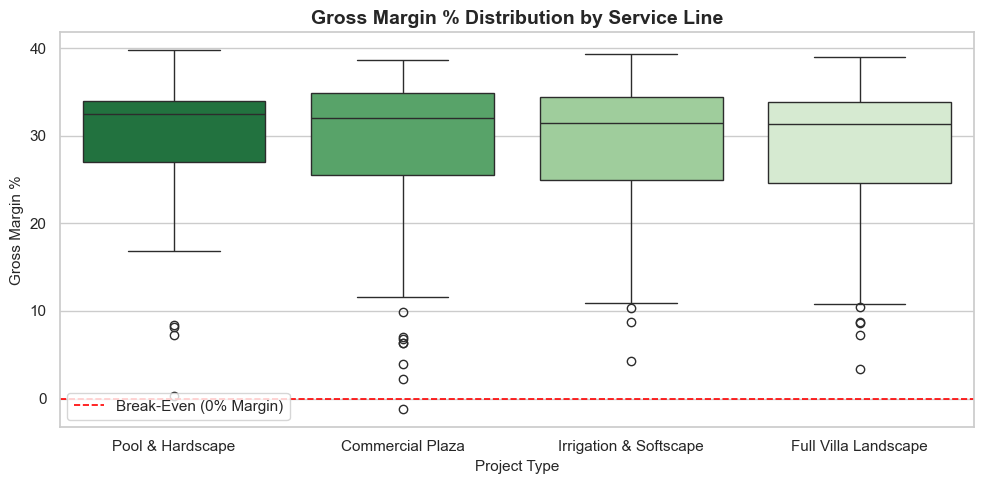

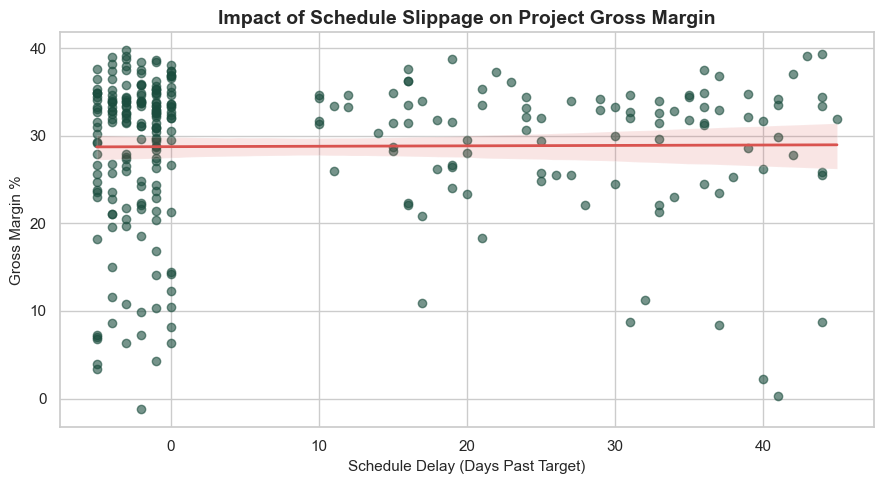

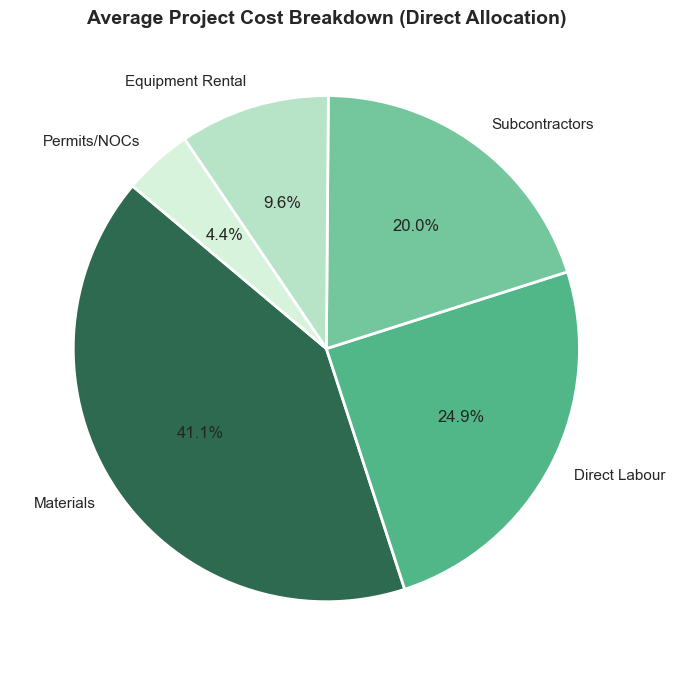

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# 1. Load the processed dataset
df = pd.read_csv("../data/processed/clean_projects_financials.csv")

# Filter completed projects for historical profitability analysis
df_completed = df[df["status"] == "Completed"].copy()

# ----------------------------------------------------
# VISUAL 1: Profit Margin % by Project Type (Boxplot)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))
order = (
    df_completed.groupby("project_type")["gross_margin_pct"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df_completed,
    x="project_type",
    y="gross_margin_pct",
    palette="Greens_r",
    order=order,
)
plt.axhline(
    0, color="red", linestyle="--", linewidth=1.2, label="Break-Even (0% Margin)"
)
plt.title(
    "Gross Margin % Distribution by Service Line", fontsize=14, weight="bold"
)
plt.xlabel("Project Type", fontsize=11)
plt.ylabel("Gross Margin %", fontsize=11)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# VISUAL 2: Schedule Delay vs. Profit Margin Erosion (Scatter)
# ----------------------------------------------------
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_completed,
    x="schedule_delay_days",
    y="gross_margin_pct",
    scatter_kws={"alpha": 0.6, "color": "#1b4d3e"},
    line_kws={"color": "#d9534f", "linewidth": 2},
)
plt.title(
    "Impact of Schedule Slippage on Project Gross Margin",
    fontsize=14,
    weight="bold",
)
plt.xlabel("Schedule Delay (Days Past Target)", fontsize=11)
plt.ylabel("Gross Margin %", fontsize=11)
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# VISUAL 3: Cost Composition Breakdown (Stacked Summary)
# ----------------------------------------------------
cost_components = [
    "material_cost_aed",
    "labour_cost_aed",
    "subcontractor_cost_aed",
    "equipment_rental_aed",
    "permitting_fees_aed",
]

avg_costs = df_completed[cost_components].mean()
cost_labels = [
    "Materials",
    "Direct Labour",
    "Subcontractors",
    "Equipment Rental",
    "Permits/NOCs",
]

plt.figure(figsize=(7, 7))
plt.pie(
    avg_costs,
    labels=cost_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#2d6a4f", "#52b788", "#74c69d", "#b7e4c7", "#d8f3dc"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
plt.title(
    "Average Project Cost Breakdown (Direct Allocation)",
    fontsize=14,
    weight="bold",
)
plt.tight_layout()
plt.show()